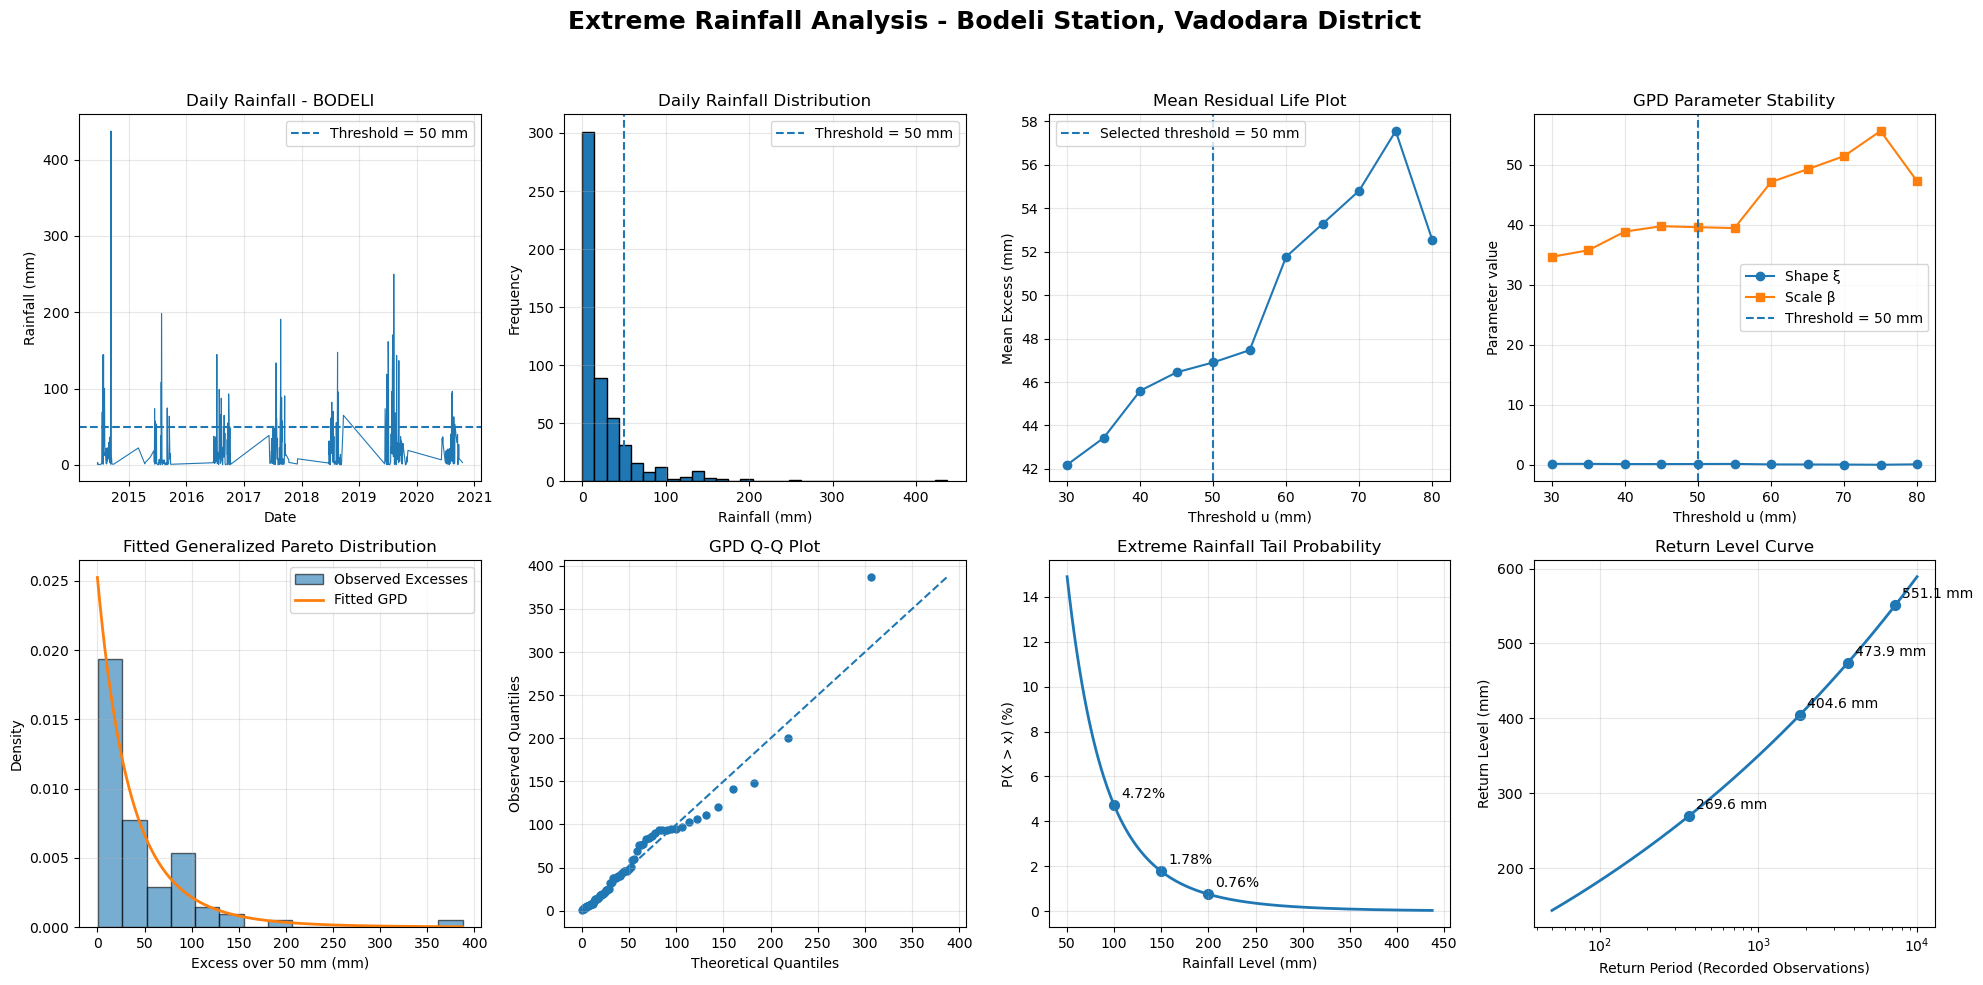


Extreme Rainfall analysis - BODELI, VADODARA
Recorded daily observations : 536
Mean rainfall               : 25.21 mm
Maximum rainfall            : 437.40 mm

Selected threshold          : 50 mm
Number of exceedances       : 80
Exceedance probability      : 0.1493
Mean excess                 : 46.9005 mm

GPD PARAMETERS
------------------------------------------------------------
Shape parameter ξ            : 0.1555
Scale parameter β            : 39.6237 mm

TAIL PROBABILITIES
------------------------------------------------------------
P(X > 100 mm)               : 4.7155%
P(X > 150 mm)               : 1.7754%
P(X > 200 mm)               : 0.7605%

RETURN LEVELS
------------------------------------------------------------
Return level (365 obs.)     : 269.65 mm
Return level (1825 obs.)     : 404.56 mm
Return level (3650 obs.)     : 473.91 mm
Return level (7300 obs.)     : 551.15 mm


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genpareto

# 1. DATA PREPARATION
FILE_PATH = r"C:\Users\victu\Downloads\3ee9f298-ad68-4d83-a6fc-2014681c958a.csv"
df = pd.read_csv(FILE_PATH)
df = df[df["Station"].astype(str).str.upper() == "BODELI"].copy()
df["datetime"] = pd.to_datetime(df["Data Acquisition Time"], dayfirst=True, errors="coerce")
df["rainfall"] = pd.to_numeric(df["Manual Daily Rainfall (mm)"], errors="coerce")
df = df.dropna(subset=["datetime", "rainfall"])
df["date"] = df["datetime"].dt.date
daily = df.groupby("date")["rainfall"].sum().sort_index()
daily.index = pd.to_datetime(daily.index)

# 2. PEAKS OVER THRESHOLD
THRESHOLD = 50.0
exceedances = daily[daily > THRESHOLD]
excesses = exceedances - THRESHOLD
n = len(daily)
n_exceedances = len(excesses)
exceedance_probability = n_exceedances / n
mean_excess = excesses.mean()

# 3. GPD FIT
xi, loc, beta = genpareto.fit(excesses.values, floc=0)
x_excess = np.linspace(0, excesses.max(), 300)
gpd_density = genpareto.pdf(x_excess, c=xi, loc=0, scale=beta)

# 4. MEAN RESIDUAL LIFE
candidate_thresholds = np.arange(30, 81, 5)
mrl_values = []
for u in candidate_thresholds:
    temp = daily[daily > u] - u
    mrl_values.append(temp.mean() if len(temp) > 0 else np.nan)
mrl_values = np.array(mrl_values)

# 5. PARAMETER STABILITY
stability_thresholds = []
shape_values = []
scale_values = []
for u in candidate_thresholds:
    temp = daily[daily > u] - u
    if len(temp) >= 10:
        shape, _, scale = genpareto.fit(temp.values, floc=0)
        stability_thresholds.append(u)
        shape_values.append(shape)
        scale_values.append(scale)
stability_thresholds = np.array(stability_thresholds)
shape_values = np.array(shape_values)
scale_values = np.array(scale_values)

# 6. TAIL PROBABILITY
def tail_probability(x):
    y = x - THRESHOLD
    if xi != 0:
        return exceedance_probability * (1 + xi * y / beta) ** (-1 / xi)
    return exceedance_probability * np.exp(-y / beta)

rainfall_levels = np.array([100, 150, 200])
tail_probabilities = np.array([tail_probability(x) for x in rainfall_levels])
tail_x = np.linspace(THRESHOLD + 0.1, max(daily.max(), 250), 300)
tail_y = np.array([tail_probability(x) for x in tail_x])

# 7. RETURN LEVEL
def return_level(T):
    if xi != 0:
        return THRESHOLD + (beta / xi) * ((T * exceedance_probability) ** xi - 1)
    return THRESHOLD + beta * np.log(T * exceedance_probability)

return_periods = np.array([365, 1825, 3650, 7300])
return_levels = np.array([return_level(T) for T in return_periods])
return_period_curve = np.logspace(np.log10(50), np.log10(10000), 300)
return_level_curve = np.array([return_level(T) for T in return_period_curve])

# 8. GPD Q-Q DATA
observed_excesses = np.sort(excesses.values)
p = (np.arange(1, len(observed_excesses) + 1) - 0.5) / len(observed_excesses)
theoretical_excesses = genpareto.ppf(p, c=xi, loc=0, scale=beta)

# 9. CREATE SUBPLOTS
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Plot 1: Daily Rainfall Time Series
axes[0].plot(daily.index, daily.values, linewidth=0.8)
axes[0].axhline(THRESHOLD, linestyle="--", linewidth=1.5, label="Threshold = 50 mm")
axes[0].set_title("Daily Rainfall - BODELI")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Rainfall (mm)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Rainfall Distribution
axes[1].hist(daily.values, bins=30, edgecolor="black")
axes[1].axvline(THRESHOLD, linestyle="--", linewidth=1.5, label="Threshold = 50 mm")
axes[1].set_title("Daily Rainfall Distribution")
axes[1].set_xlabel("Rainfall (mm)")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Mean Residual Life
axes[2].plot(candidate_thresholds, mrl_values, marker="o", linewidth=1.5)
axes[2].axvline(THRESHOLD, linestyle="--", linewidth=1.5, label="Selected threshold = 50 mm")
axes[2].set_title("Mean Residual Life Plot")
axes[2].set_xlabel("Threshold u (mm)")
axes[2].set_ylabel("Mean Excess (mm)")
axes[2].legend()
axes[2].grid(alpha=0.3)

# Plot 4: Parameter Stability
axes[3].plot(stability_thresholds, shape_values, marker="o", linewidth=1.5, label="Shape ξ")
axes[3].plot(stability_thresholds, scale_values, marker="s", linewidth=1.5, label="Scale β")
axes[3].axvline(THRESHOLD, linestyle="--", linewidth=1.5, label="Threshold = 50 mm")
axes[3].set_title("GPD Parameter Stability")
axes[3].set_xlabel("Threshold u (mm)")
axes[3].set_ylabel("Parameter value")
axes[3].legend()
axes[3].grid(alpha=0.3)

# Plot 5: Fitted GPD
axes[4].hist(excesses.values, bins=15, density=True, alpha=0.6, edgecolor="black", label="Observed Excesses")
axes[4].plot(x_excess, gpd_density, linewidth=2, label="Fitted GPD")
axes[4].set_title("Fitted Generalized Pareto Distribution")
axes[4].set_xlabel("Excess over 50 mm (mm)")
axes[4].set_ylabel("Density")
axes[4].legend()
axes[4].grid(alpha=0.3)

# Plot 6: GPD Q-Q Plot
axes[5].scatter(theoretical_excesses, observed_excesses, s=25)
qmin = min(theoretical_excesses.min(), observed_excesses.min())
qmax = max(theoretical_excesses.max(), observed_excesses.max())
axes[5].plot([qmin, qmax], [qmin, qmax], linestyle="--", linewidth=1.5)
axes[5].set_title("GPD Q-Q Plot")
axes[5].set_xlabel("Theoretical Quantiles")
axes[5].set_ylabel("Observed Quantiles")
axes[5].grid(alpha=0.3)

# Plot 7: Tail Probability
axes[6].plot(tail_x, tail_y * 100, linewidth=2)
axes[6].scatter(rainfall_levels, tail_probabilities * 100, s=50)
for x, p in zip(rainfall_levels, tail_probabilities):
    axes[6].annotate(f"{p*100:.2f}%", (x, p*100), xytext=(5,5), textcoords="offset points")
axes[6].set_title("Extreme Rainfall Tail Probability")
axes[6].set_xlabel("Rainfall Level (mm)")
axes[6].set_ylabel("P(X > x) (%)")
axes[6].grid(alpha=0.3)

# Plot 8: Return Level
axes[7].plot(return_period_curve, return_level_curve, linewidth=2)
axes[7].scatter(return_periods, return_levels, s=50)
for T, z in zip(return_periods, return_levels):
    axes[7].annotate(f"{z:.1f} mm", (T, z), xytext=(5,5), textcoords="offset points")
axes[7].set_xscale("log")
axes[7].set_title("Return Level Curve")
axes[7].set_xlabel("Return Period (Recorded Observations)")
axes[7].set_ylabel("Return Level (mm)")
axes[7].grid(alpha=0.3)

fig.suptitle("Extreme Rainfall Analysis - Bodeli Station, Vadodara District", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(r"C:\Users\victu\Downloads\EVT_BODELI_All_Plots.png", dpi=300, bbox_inches="tight")
plt.show()

# 10. RESULTS
print("\n" + "=" * 60)
print("Extreme Rainfall analysis - BODELI, VADODARA")
print("=" * 60)
print(f"Recorded daily observations : {n}")
print(f"Mean rainfall               : {daily.mean():.2f} mm")
print(f"Maximum rainfall            : {daily.max():.2f} mm")
print(f"\nSelected threshold          : {THRESHOLD:.0f} mm")
print(f"Number of exceedances       : {n_exceedances}")
print(f"Exceedance probability      : {exceedance_probability:.4f}")
print(f"Mean excess                 : {mean_excess:.4f} mm")

print("\nGPD PARAMETERS")
print("-" * 60) 
print(f"Shape parameter ξ            : {xi:.4f}")
print(f"Scale parameter β            : {beta:.4f} mm")

print("\nTAIL PROBABILITIES")
print("-" * 60) 
for x, p in zip(rainfall_levels, tail_probabilities):
    print(f"P(X > {x} mm)               : {p*100:.4f}%")

print("\nRETURN LEVELS")
print("-" * 60)
for T, z in zip(return_periods, return_levels):
    print(f"Return level ({T} obs.)     : {z:.2f} mm")